# Test Performance Analysis
In this notebook, we analyze the performance of the selected models on the test dataset and account for trading costs on rebalancing.

### Setup

In [ ]:
# All imports
import sys
from pathlib import Path

# Get the absolute path of the directory one level up
root_dir = Path.cwd().parent

# Add it to sys.path if it's not already there
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import os
import numpy as np
import pandas as pd

from scipy import stats
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import plotly.graph_objects as go
from src.utils.io import load_path_config, load_json
from src.data_processing.loading import load_single_csv
from src.utils.constants import EQ_WT_NAME, SP500_NAME
from src.utils.formatting import deserialize_np_dict
from src.evaluation.evaluator import Evaluator
from src.evaluation.selection import pareto_dominance, high_corr_with_each_metric
from src.visualization.plots import plot_3d_pareto, plot_corr

from src.evaluation.metrics import MetricLibrary
from src.models.registry import NNModelLibrary, TradModelLibrary

In [2]:
paths_config = load_path_config(os.path.join('../config', 'paths.json'))

# Convert str paths to Path
artifacts_paths = {}
for name, path in paths_config['artifacts'].items():
    dir_path = Path('../'+ path)
    artifacts_paths[name] = dir_path

TradModelLibrary.autodiscover('src.models')
# Registering all NN models to the library
NNModelLibrary.autodiscover('src.models') # MUST be executed for model registration

### Loading Test Set Performance

In [3]:
NUM_SEEDS = 2

test_avg_perf = load_single_csv(
    artifacts_paths['test_perf_dir'] / f'avg_test_perf_all_{NUM_SEEDS}_seeds.csv',
    index_dt=False
)

# Daily returns for all models at all steps
test_returns = load_json(artifacts_paths['test_perf_dir'] / 'test_returns_all.json')

test_avg_perf

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
Equal_Weight,-0.011262,-0.009038,-0.001388,-0.095187,-0.022625,0.993425,0.002025
GlobalMinimumVariance,-0.010738,-0.024800,-0.028788,-0.084675,-0.019662,0.958025,-0.000988
HierarchialRiskParity,-0.008913,-0.010000,-0.004387,-0.087700,-0.020313,0.991587,0.001150
MeanVariancePortfolio,-0.047062,-0.043537,-0.071163,-0.156463,-0.034100,0.919462,-0.002475
NaiveMVP,-0.010738,-0.024775,-0.028800,-0.084675,-0.019662,0.958037,-0.000988
NestedClusteredOptimization,-0.000562,-0.005237,-0.012150,-0.081738,-0.020000,1.000825,-0.000025
S&P500,-0.003225,0.021125,0.048837,-0.091500,-0.023213,1.087338,0.008900
TemporalTransformer-custom_loss_11,0.014562,0.019431,0.035088,-0.096919,-0.027912,1.063456,0.005312


### Overall Performance Analysis
Analysis of model performances on the test set across multiple seeds. seeds = [42, 123]

<Axes: title={'center': 'Mean Sharpe (Over All Seeds) vs Portfolio Optimizer'}>

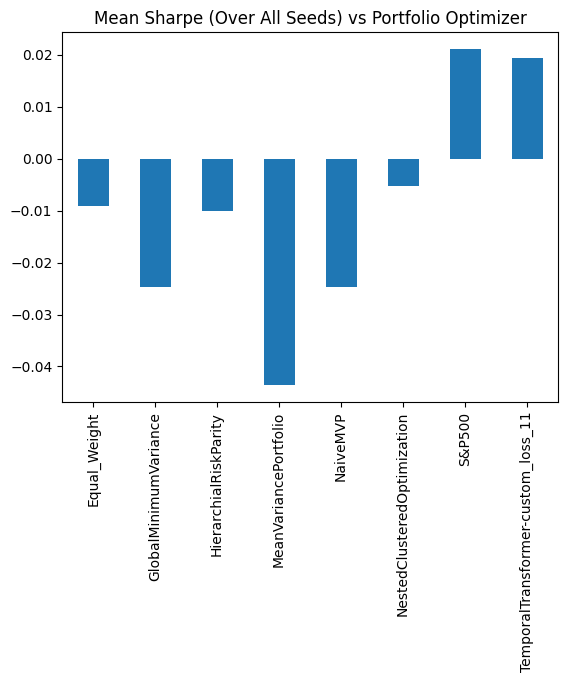

In [4]:
test_avg_perf['sharpe'].plot.bar(title='Mean Sharpe (Over All Seeds) vs Portfolio Optimizer')

<Axes: title={'center': 'Mean CVaR (Over All Seeds) vs Portfolio Optimizer'}>

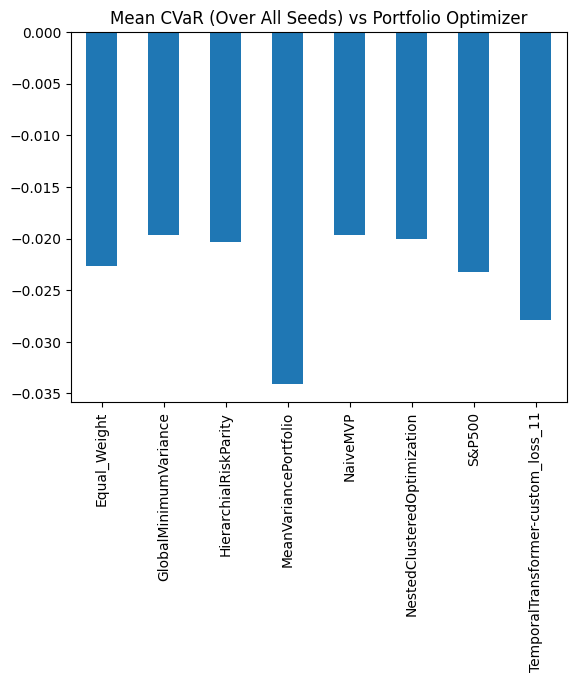

In [5]:
test_avg_perf['cvar'].plot.bar(title='Mean CVaR (Over All Seeds) vs Portfolio Optimizer')

<Axes: title={'center': 'Mean Compounded Returns (Over All Seeds) vs Portfolio Optimizer'}>

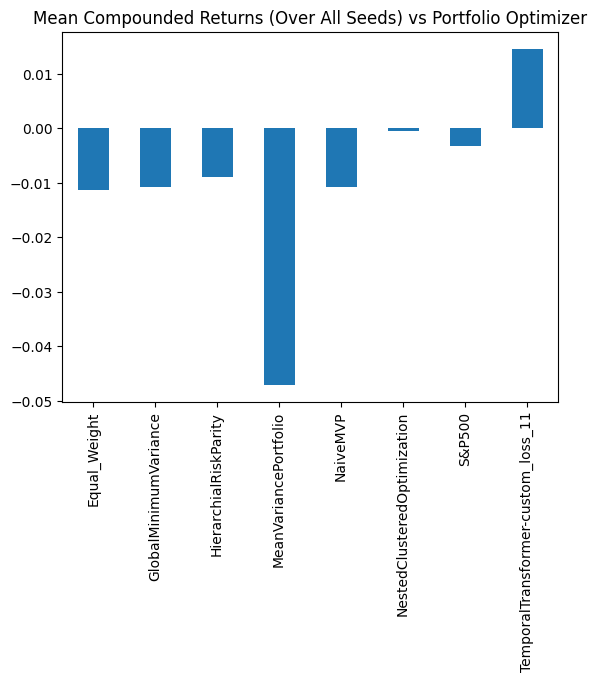

In [6]:
test_avg_perf['compunded_return'].plot.bar(title='Mean Compounded Returns (Over All Seeds) vs Portfolio Optimizer')

#### Mean Metrics Pareto Frontier and Correlation Analysis

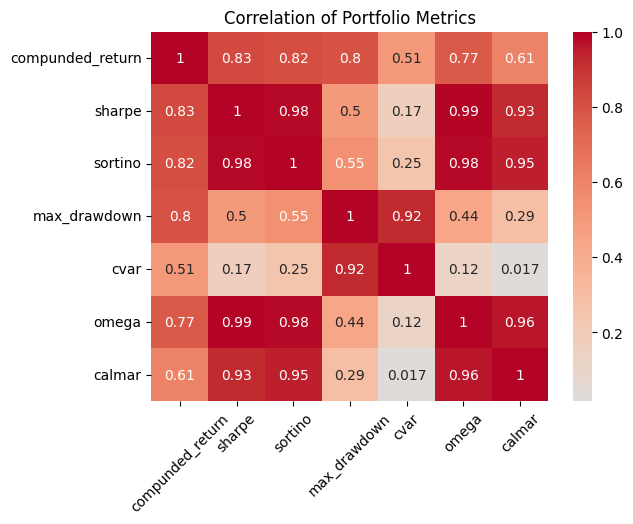


compunded_return is highly correlated with:
  sharpe: 0.833
  sortino: 0.819
  max_drawdown: 0.798
  omega: 0.770

sharpe is highly correlated with:
  compunded_return: 0.833
  sortino: 0.984
  omega: 0.991
  calmar: 0.927

sortino is highly correlated with:
  compunded_return: 0.819
  sharpe: 0.984
  omega: 0.981
  calmar: 0.947

max_drawdown is highly correlated with:
  compunded_return: 0.798
  cvar: 0.922

cvar is highly correlated with:
  max_drawdown: 0.922

omega is highly correlated with:
  compunded_return: 0.770
  sharpe: 0.991
  sortino: 0.981
  calmar: 0.963

calmar is highly correlated with:
  sharpe: 0.927
  sortino: 0.947
  omega: 0.963


In [7]:
corr = test_avg_perf.corr()

plot_corr(corr, title='Correlation of Portfolio Metrics')
high_corr_with_each_metric(corr, threshold=0.75)

In [9]:
temp_avg_perf = test_avg_perf.copy()

cols = ['sharpe', 'compunded_return', 'cvar']
temp_avg_perf['dominated_3d'] = pareto_dominance(test_avg_perf, cols)

frontier_3d = test_avg_perf[~temp_avg_perf['dominated_3d']]

fig = plot_3d_pareto(
    df=temp_avg_perf,
    x_col='sharpe',
    y_col='compunded_return',
    z_col='cvar',
    dominated_col='dominated_3d',
    title='3D Pareto Frontier - Mean (Sharpe, Compounded Return, CVaR)',
    x_title='Sharpe Ratio',
    y_title='Compounded Return',
    z_title='CVaR (higher better)'
)

fig.show()
frontier_3d

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
NaiveMVP,-0.010738,-0.024775,-0.028800,-0.084675,-0.019662,0.958037,-0.000988
NestedClusteredOptimization,-0.000562,-0.005237,-0.012150,-0.081738,-0.020000,1.000825,-0.000025
S&P500,-0.003225,0.021125,0.048837,-0.091500,-0.023213,1.087338,0.008900
TemporalTransformer-custom_loss_11,0.014562,0.019431,0.035088,-0.096919,-0.027912,1.063456,0.005312


#### Calculating Multi-Seed Statistics

In [10]:
all_models = []
for cat in NNModelLibrary.list_categories():
    all_models.extend(NNModelLibrary.list_models(cat))

In [ ]:
# Deserialize dict: replace lists with np.array()
test_returns_deserial = deserialize_np_dict(test_returns)

# Separate NN and benchmarks
all_benches = TradModelLibrary.list_models()
all_benches.extend([EQ_WT_NAME, SP500_NAME])

nn_seed_rets = {}
bench_rets = {}
for seed_or_bench, modls_dict in test_returns_deserial.items():
    if seed_or_bench in all_benches:
        bench_rets[seed_or_bench] = modls_dict
    else:
        nn_seed_rets[seed_or_bench] = modls_dict

In [16]:
# Remove date range keys
nn_seed_rets_no_dates = {seed: {} for seed in nn_seed_rets.keys()}
for seed, seed_perfs in nn_seed_rets.items():
    for modl_name, windows_dict in seed_perfs.items():
        nn_seed_rets_no_dates[seed][modl_name] = np.stack(
            [wind_rets for dates, wind_rets in windows_dict.items()]
        )

Calculate Lower Confidence Bound for all models over all seeds (better estimate of overall performance).

In [ ]:
seed_metric_dfs = []
for seed, seed_perfs in nn_seed_rets_no_dates.items():
    evaluator = Evaluator(
        eval_returns=None,
        ba_eval=None,
        all_daily_returns=seed_perfs,
        metrics_lib=MetricLibrary.items()
    )
    seed_metric_dfs.append(evaluator.calc_pf_performances())

# Stats Calculation
n = pd.concat(seed_metric_dfs).groupby(level=0).count()
avg_perf_metrics = pd.concat(seed_metric_dfs).groupby(level=0).mean() # Average over seeds
std_perf_metrics = pd.concat(seed_metric_dfs).groupby(level=0).std(ddof=1) # Std across seeds

# Extract the common n (assuming all models have same count)
n_seeds = n.iloc[0, 0]   # or n['sharpe'].iloc[0] if column exists

# Critical t-value for one‑sided 95% confidence
t_val = stats.t.ppf(0.95, df=n_seeds-1)

lower_bound_df = avg_perf_metrics - t_val * (std_perf_metrics / np.sqrt(n_seeds))

Adding benchmarks and tradional models to the above dataframe. We do not need to calculate lower bound for the benchmarks/tradional models because they were not run for multiple seeds. Hence, consider the mean metrics over all windows as their overall performance.


In [18]:
lower_bound_df = pd.concat(
    [lower_bound_df, test_avg_perf[test_avg_perf.index.isin(all_benches)]],
    axis=0
)
lower_bound_df

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
TemporalTransformer-custom_loss_11,-0.054494,-0.066870,-0.108708,-0.108796,-0.031069,0.840226,-0.001948
Equal_Weight,-0.011262,-0.009038,-0.001388,-0.095187,-0.022625,0.993425,0.002025
GlobalMinimumVariance,-0.010738,-0.024800,-0.028788,-0.084675,-0.019662,0.958025,-0.000988
HierarchialRiskParity,-0.008913,-0.010000,-0.004387,-0.087700,-0.020313,0.991587,0.001150
MeanVariancePortfolio,-0.047062,-0.043537,-0.071163,-0.156463,-0.034100,0.919462,-0.002475
NaiveMVP,-0.010738,-0.024775,-0.028800,-0.084675,-0.019662,0.958037,-0.000988
NestedClusteredOptimization,-0.000562,-0.005237,-0.012150,-0.081738,-0.020000,1.000825,-0.000025
S&P500,-0.003225,0.021125,0.048837,-0.091500,-0.023213,1.087338,0.008900


#### Lower Confidence Bound Metrics Pareto Frontier Analysis

Pareto Frontier for all metrics

In [19]:
temp_lcb = lower_bound_df.copy()

temp_lcb['dominated'] = pareto_dominance(temp_lcb, list(temp_lcb.columns))

frontier_3d = temp_lcb[~temp_lcb['dominated']]
frontier_3d

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar,dominated
Equal_Weight,-0.011262,-0.009038,-0.001388,-0.095187,-0.022625,0.993425,0.002025,False
GlobalMinimumVariance,-0.010738,-0.024800,-0.028788,-0.084675,-0.019662,0.958025,-0.000988,False
HierarchialRiskParity,-0.008913,-0.010000,-0.004387,-0.087700,-0.020313,0.991587,0.001150,False
NaiveMVP,-0.010738,-0.024775,-0.028800,-0.084675,-0.019662,0.958037,-0.000988,False
NestedClusteredOptimization,-0.000562,-0.005237,-0.012150,-0.081738,-0.020000,1.000825,-0.000025,False
S&P500,-0.003225,0.021125,0.048837,-0.091500,-0.023213,1.087338,0.008900,False


Metric Correlation Analysis and 3D Pareto Frontier

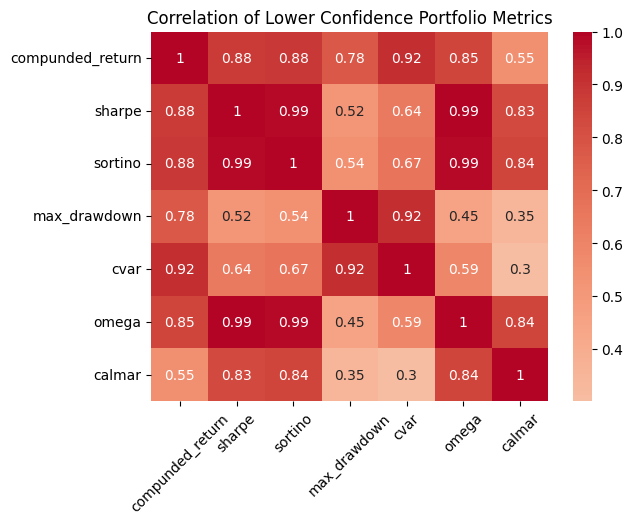


compunded_return is highly correlated with:
  sharpe: 0.883
  sortino: 0.883
  max_drawdown: 0.782
  cvar: 0.917
  omega: 0.849

sharpe is highly correlated with:
  compunded_return: 0.883
  sortino: 0.991
  omega: 0.995
  calmar: 0.831

sortino is highly correlated with:
  compunded_return: 0.883
  sharpe: 0.991
  omega: 0.988
  calmar: 0.843

max_drawdown is highly correlated with:
  compunded_return: 0.782
  cvar: 0.917

cvar is highly correlated with:
  compunded_return: 0.917
  max_drawdown: 0.917

omega is highly correlated with:
  compunded_return: 0.849
  sharpe: 0.995
  sortino: 0.988
  calmar: 0.843

calmar is highly correlated with:
  sharpe: 0.831
  sortino: 0.843
  omega: 0.843


In [21]:
corr = lower_bound_df.corr()

plot_corr(corr, title='Correlation of Lower Confidence Portfolio Metrics')
high_corr_with_each_metric(corr, threshold=0.75)

In [22]:
temp_lcb = lower_bound_df.copy()
cols = ['sharpe', 'compunded_return', 'cvar']
temp_lcb['dominated_3d'] = pareto_dominance(temp_lcb, cols)

frontier_3d = temp_lcb[~temp_lcb['dominated_3d']]
fig = plot_3d_pareto(
    df=temp_lcb,
    x_col='sharpe',
    y_col='compunded_return',
    z_col='cvar',
    dominated_col='dominated_3d',
    title='3D Pareto Frontier Lower Confidence Bound (Sharpe, Compounded Return, CVaR)',
    x_title='Sharpe Ratio',
    y_title='Compounded Return',
    z_title='CVaR (higher better)'
)

fig.show()
frontier_3d

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar,dominated_3d
NaiveMVP,-0.010738,-0.024775,-0.028800,-0.084675,-0.019662,0.958037,-0.000988,False
NestedClusteredOptimization,-0.000562,-0.005237,-0.012150,-0.081738,-0.020000,1.000825,-0.000025,False
S&P500,-0.003225,0.021125,0.048837,-0.091500,-0.023213,1.087338,0.008900,False
